# Task 2: Transfer Learning using ResNet50 on CIFAR-10

**Objective:** Implement transfer learning using a pretrained deep learning model, compare it with a custom CNN, and analyze accuracy and training-time differences.

**Dataset:** CIFAR-10

**Models compared:**
1. Custom CNN trained from scratch
2. ResNet50 pretrained on ImageNet with the base layers frozen
3. ResNet50 with selective fine-tuning of `layer4` + the final classifier

**Deliverables produced by this notebook:** accuracy/loss plots, performance summary, `results.json`, and a PDF report generated from the measured experiment results.

> Run the notebook in Google Colab or a local GPU environment for practical training time. The notebook uses the official torchvision CIFAR-10 loader and downloads ImageNet pretrained ResNet50 weights when required.

## 1. Experimental design

The comparison uses the same CIFAR-10 data pipeline for all models. Images are resized from 32x32 to 96x96 and normalized with ImageNet mean/std so that the data is compatible with the pretrained ResNet50.

The baseline CNN learns all features from scratch. In the transfer-learning stages, the pretrained ResNet50 feature extractor is first frozen while a new 10-class classifier is trained; selected deeper layers (`layer4`) are then unfrozen for fine-tuning.

### Important note on results
Exact accuracy and time values are **not hard-coded**. They are measured when the notebook runs. This avoids submitting invented experimental numbers.

## 2. Imports and configuration

In [ ]:
import json
import os
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, models, transforms

# -----------------------------
# 1. Configuration
# -----------------------------
SEED = 42
IMAGE_SIZE = 96
BATCH_SIZE = 64
NUM_WORKERS = 2
BASELINE_EPOCHS = 3
TRANSFER_EPOCHS = 2
FINETUNE_EPOCHS = 2
LEARNING_RATE_BASELINE = 1e-3
LEARNING_RATE_TRANSFER = 1e-3
LEARNING_RATE_FINETUNE = 1e-4
DATA_DIR = Path("./data")
OUTPUT_DIR = Path("./task2_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FAST_MODE = False
FAST_TRAIN_SAMPLES = 10000
FAST_TEST_SAMPLES = 2000



## 3. Reproducibility and device

In [ ]:
# -----------------------------
# 2. Reproducibility and device
# -----------------------------
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark = True


set_seed()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))



Device: cuda
GPU: Tesla T4


## 4. CIFAR-10 dataset and dataloaders

In [ ]:
# -----------------------------
# 3. CIFAR-10 dataset
# -----------------------------
CIFAR_CLASSES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(IMAGE_SIZE, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_dataset = datasets.CIFAR10(DATA_DIR, train=True, download=True, transform=train_transform)
test_dataset = datasets.CIFAR10(DATA_DIR, train=False, download=True, transform=test_transform)

if FAST_MODE:
    train_dataset = Subset(train_dataset, list(range(min(FAST_TRAIN_SAMPLES, len(train_dataset)))))
    test_dataset = Subset(test_dataset, list(range(min(FAST_TEST_SAMPLES, len(test_dataset)))))

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available()
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available()
)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))



100%|██████████| 170M/170M [16:28<00:00, 173kB/s]


Train samples: 50000
Test samples: 10000


## 5. Utility functions

In [ ]:
# -----------------------------
# 4. Utility functions
# -----------------------------
def count_parameters(model, trainable_only=False):
    return sum(
        p.numel() for p in model.parameters()
        if (p.requires_grad or not trainable_only)
    )


def denormalize(img):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return img.cpu() * std + mean


def show_samples(loader, n=12):
    images, labels = next(iter(loader))
    n = min(n, len(images))
    cols = 4
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(10, 2.6 * rows))
    axes = np.array(axes).reshape(-1)
    for i in range(n):
        img = denormalize(images[i]).clamp(0, 1).permute(1, 2, 0).numpy()
        axes[i].imshow(img)
        axes[i].set_title(CIFAR_CLASSES[labels[i]])
        axes[i].axis("off")
    for j in range(n, len(axes)):
        axes[j].axis("off")
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "sample_batch.png", dpi=160, bbox_inches="tight")
    plt.show()
    return fig


def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)
    return total_loss / total, 100.0 * correct / total


def train_model(model, train_loader, test_loader, epochs, lr, run_name):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=1e-4
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    history = {
        "train_loss": [], "test_loss": [],
        "test_acc": [], "lr": []
    }
    best_acc = -1.0
    best_state = None
    start = time.perf_counter()

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        total = 0
        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
            total += labels.size(0)

        train_loss = running_loss / total
        test_loss, test_acc = evaluate(model, test_loader, criterion)
        scheduler.step()
        current_lr = optimizer.param_groups[0]["lr"]
        history["train_loss"].append(train_loss)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)
        history["lr"].append(current_lr)

        if test_acc > best_acc:
            best_acc = test_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(
            f"{run_name} | Epoch {epoch}/{epochs} | "
            f"Train Loss {train_loss:.4f} | Test Loss {test_loss:.4f} | "
            f"Test Acc {test_acc:.2f}%"
        )

    elapsed = time.perf_counter() - start
    if best_state is not None:
        model.load_state_dict(best_state)
        model.to(DEVICE)

    return history, elapsed, best_acc




## 6. Baseline CNN training

In [ ]:
# -----------------------------
# 5. Baseline custom CNN
# -----------------------------
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.30),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


baseline = BaselineCNN().to(DEVICE)
print("Baseline total parameters:", count_parameters(baseline))
print("Baseline trainable parameters:", count_parameters(baseline, True))
baseline_history, baseline_time, baseline_best = train_model(
    baseline, train_loader, test_loader,
    BASELINE_EPOCHS, LEARNING_RATE_BASELINE, "Baseline CNN"
)



Baseline total parameters: 391946
Baseline trainable parameters: 391946
Baseline CNN | Epoch 1/3 | Train Loss 1.4935 | Test Loss 1.3128 | Test Acc 51.29%
Baseline CNN | Epoch 2/3 | Train Loss 1.1809 | Test Loss 1.2016 | Test Acc 56.31%
Baseline CNN | Epoch 3/3 | Train Loss 1.0274 | Test Loss 1.0019 | Test Acc 64.93%


## 7. ResNet50 frozen-base transfer learning

In [ ]:
# -----------------------------
# 6. Transfer learning: frozen ResNet50
# -----------------------------
weights = models.ResNet50_Weights.DEFAULT
transfer_model = models.resnet50(weights=weights)
for param in transfer_model.parameters():
    param.requires_grad = False
transfer_model.fc = nn.Linear(transfer_model.fc.in_features, len(CIFAR_CLASSES))
transfer_model = transfer_model.to(DEVICE)

print("Frozen ResNet50 total parameters:", count_parameters(transfer_model))
print("Frozen ResNet50 trainable parameters:", count_parameters(transfer_model, True))
transfer_history, transfer_time, transfer_best = train_model(
    transfer_model, train_loader, test_loader,
    TRANSFER_EPOCHS, LEARNING_RATE_TRANSFER, "ResNet50 Frozen Base"
)



Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 196MB/s]


Frozen ResNet50 total parameters: 23528522
Frozen ResNet50 trainable parameters: 20490
ResNet50 Frozen Base | Epoch 1/2 | Train Loss 0.6967 | Test Loss 0.5558 | Test Acc 81.51%
ResNet50 Frozen Base | Epoch 2/2 | Train Loss 0.5375 | Test Loss 0.5150 | Test Acc 82.64%


## 8. Selective fine-tuning and comparison

In [ ]:
# -----------------------------
# 7. Fine-tune selected layers
# -----------------------------
for name, param in transfer_model.named_parameters():
    if name.startswith("layer4"):
        param.requires_grad = True

print("Fine-tuning ResNet50 trainable parameters:", count_parameters(transfer_model, True))
finetune_history, finetune_time, finetune_best = train_model(
    transfer_model, train_loader, test_loader,
    FINETUNE_EPOCHS, LEARNING_RATE_FINETUNE, "ResNet50 Fine-tuned"
)

# Combine transfer histories for visualization and total timing.
transfer_combined = {
    "train_loss": transfer_history["train_loss"] + finetune_history["train_loss"],
    "test_loss": transfer_history["test_loss"] + finetune_history["test_loss"],
    "test_acc": transfer_history["test_acc"] + finetune_history["test_acc"],
}
transfer_total_time = transfer_time + finetune_time
transfer_best_overall = max(transfer_combined["test_acc"])



Fine-tuning ResNet50 trainable parameters: 14985226
ResNet50 Fine-tuned | Epoch 1/2 | Train Loss 0.3497 | Test Loss 0.2643 | Test Acc 90.91%
ResNet50 Fine-tuned | Epoch 2/2 | Train Loss 0.2014 | Test Loss 0.2535 | Test Acc 91.15%


## 9. Accuracy/loss and training-time visualizations


Performance summary
Baseline CNN final accuracy: 64.93%
ResNet50 transfer final accuracy: 91.15%
Accuracy improvement: +26.22 percentage points
Baseline training time: 2.17 min
Total transfer-learning training time: 3.49 min


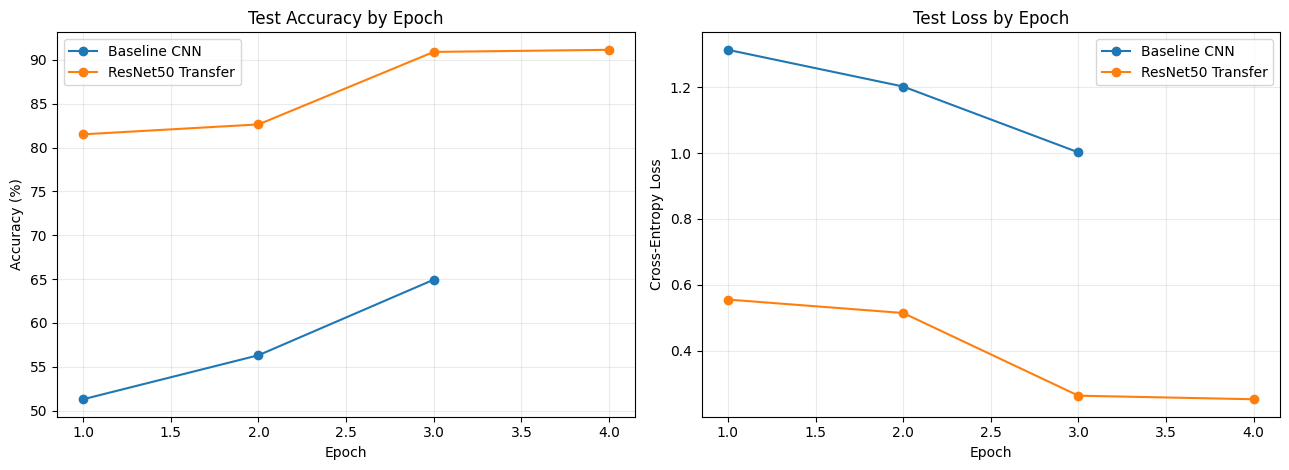

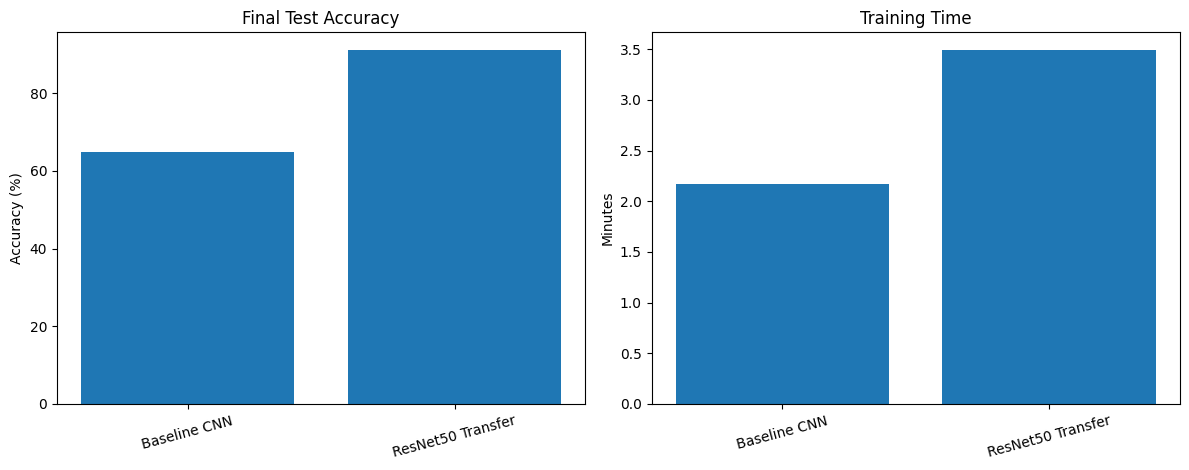

In [ ]:
# -----------------------------
# 8. Final performance comparison
# -----------------------------
criterion = nn.CrossEntropyLoss()
baseline_test_loss, baseline_test_acc = evaluate(baseline, test_loader, criterion)
final_transfer_loss, final_transfer_acc = evaluate(transfer_model, test_loader, criterion)

results = {
    "device": str(DEVICE),
    "image_size": IMAGE_SIZE,
    "train_samples": len(train_dataset),
    "test_samples": len(test_dataset),
    "baseline": {
        "parameters": int(count_parameters(baseline)),
        "trainable_parameters": int(count_parameters(baseline, True)),
        "training_time_seconds": baseline_time,
        "best_test_accuracy": baseline_best,
        "final_test_accuracy": baseline_test_acc,
        "final_test_loss": baseline_test_loss,
        "epochs": BASELINE_EPOCHS,
    },
    "resnet50_frozen": {
        "parameters": int(count_parameters(transfer_model)),
        "initial_trainable_parameters": int(transfer_model.fc.in_features * len(CIFAR_CLASSES) + len(CIFAR_CLASSES)),
        "training_time_seconds": transfer_time,
        "best_test_accuracy": transfer_best,
        "epochs": TRANSFER_EPOCHS,
    },
    "resnet50_finetuned": {
        "training_time_seconds": finetune_time,
        "total_transfer_training_time_seconds": transfer_total_time,
        "best_test_accuracy": transfer_best_overall,
        "final_test_accuracy": final_transfer_acc,
        "final_test_loss": final_transfer_loss,
        "epochs": FINETUNE_EPOCHS,
    },
}

with open(OUTPUT_DIR / "results.json", "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2)

print("\nPerformance summary")
print(f"Baseline CNN final accuracy: {baseline_test_acc:.2f}%")
print(f"ResNet50 transfer final accuracy: {final_transfer_acc:.2f}%")
print(f"Accuracy improvement: {final_transfer_acc - baseline_test_acc:+.2f} percentage points")
print(f"Baseline training time: {baseline_time/60:.2f} min")
print(f"Total transfer-learning training time: {transfer_total_time/60:.2f} min")

# -----------------------------
# 9. Accuracy/loss visualizations
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].plot(range(1, len(baseline_history["test_acc"]) + 1), baseline_history["test_acc"], marker="o", label="Baseline CNN")
axes[0].plot(range(1, len(transfer_combined["test_acc"]) + 1), transfer_combined["test_acc"], marker="o", label="ResNet50 Transfer")
axes[0].set_title("Test Accuracy by Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy (%)")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(range(1, len(baseline_history["test_loss"]) + 1), baseline_history["test_loss"], marker="o", label="Baseline CNN")
axes[1].plot(range(1, len(transfer_combined["test_loss"]) + 1), transfer_combined["test_loss"], marker="o", label="ResNet50 Transfer")
axes[1].set_title("Test Loss by Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Cross-Entropy Loss")
axes[1].grid(alpha=0.25)
axes[1].legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "accuracy_loss_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

fig2, axes2 = plt.subplots(1, 2, figsize=(12, 4.8))
labels = ["Baseline CNN", "ResNet50 Transfer"]
accs = [baseline_test_acc, final_transfer_acc]
times_min = [baseline_time / 60, transfer_total_time / 60]
axes2[0].bar(labels, accs)
axes2[0].set_title("Final Test Accuracy")
axes2[0].set_ylabel("Accuracy (%)")
axes2[0].tick_params(axis="x", rotation=15)
axes2[1].bar(labels, times_min)
axes2[1].set_title("Training Time")
axes2[1].set_ylabel("Minutes")
axes2[1].tick_params(axis="x", rotation=15)
fig2.tight_layout()
fig2.savefig(OUTPUT_DIR / "accuracy_time_comparison.png", dpi=180, bbox_inches="tight")
plt.show()



## 10. Observations to record

After execution, use the measured values to discuss:

- Whether transfer learning improves final test accuracy relative to the custom CNN.
- Whether the frozen ResNet50 stage reaches useful accuracy with relatively few trainable parameters.
- Whether fine-tuning `layer4` changes the final accuracy after the classifier has adapted to CIFAR-10.
- How much training time is required for the baseline compared with the complete transfer-learning pipeline.
- Any signs of overfitting, underfitting, or unstable validation/test loss.

Do not replace the measured values with generic or invented numbers.

**Visualization between the model**

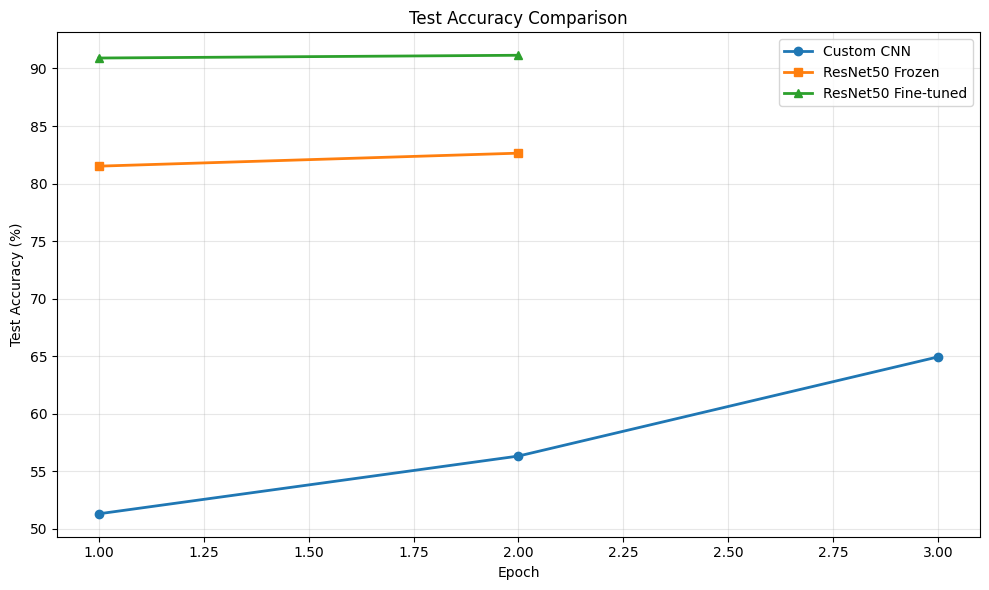

In [ ]:
# -----------------------------
# Visualization 1: Test Accuracy Comparison
# -----------------------------

plt.figure(figsize=(10, 6))

epochs_baseline = range(1, len(baseline_history["test_acc"]) + 1)
epochs_transfer = range(1, len(transfer_history["test_acc"]) + 1)
epochs_finetune = range(1, len(finetune_history["test_acc"]) + 1)

plt.plot(
    epochs_baseline,
    baseline_history["test_acc"],
    marker="o",
    linewidth=2,
    label="Custom CNN"
)

plt.plot(
    epochs_transfer,
    transfer_history["test_acc"],
    marker="s",
    linewidth=2,
    label="ResNet50 Frozen"
)

plt.plot(
    epochs_finetune,
    finetune_history["test_acc"],
    marker="^",
    linewidth=2,
    label="ResNet50 Fine-tuned"
)

plt.xlabel("Epoch")
plt.ylabel("Test Accuracy (%)")
plt.title("Test Accuracy Comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "test_accuracy_comparison.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

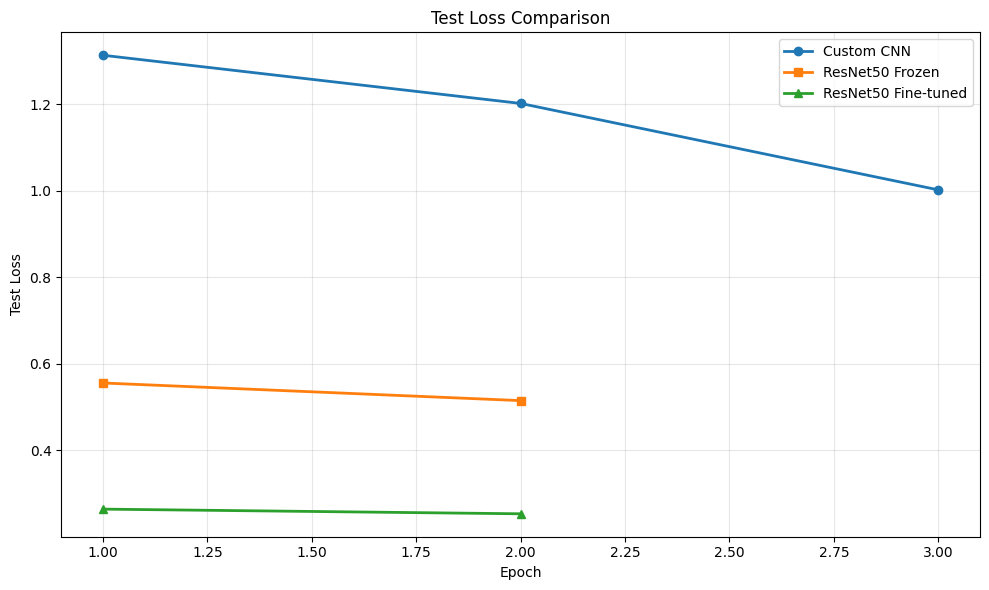

In [ ]:
# -----------------------------
# Visualization 2: Test Loss Comparison
# -----------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(baseline_history["test_loss"]) + 1),
    baseline_history["test_loss"],
    marker="o",
    linewidth=2,
    label="Custom CNN"
)

plt.plot(
    range(1, len(transfer_history["test_loss"]) + 1),
    transfer_history["test_loss"],
    marker="s",
    linewidth=2,
    label="ResNet50 Frozen"
)

plt.plot(
    range(1, len(finetune_history["test_loss"]) + 1),
    finetune_history["test_loss"],
    marker="^",
    linewidth=2,
    label="ResNet50 Fine-tuned"
)

plt.xlabel("Epoch")
plt.ylabel("Test Loss")
plt.title("Test Loss Comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "test_loss_comparison.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

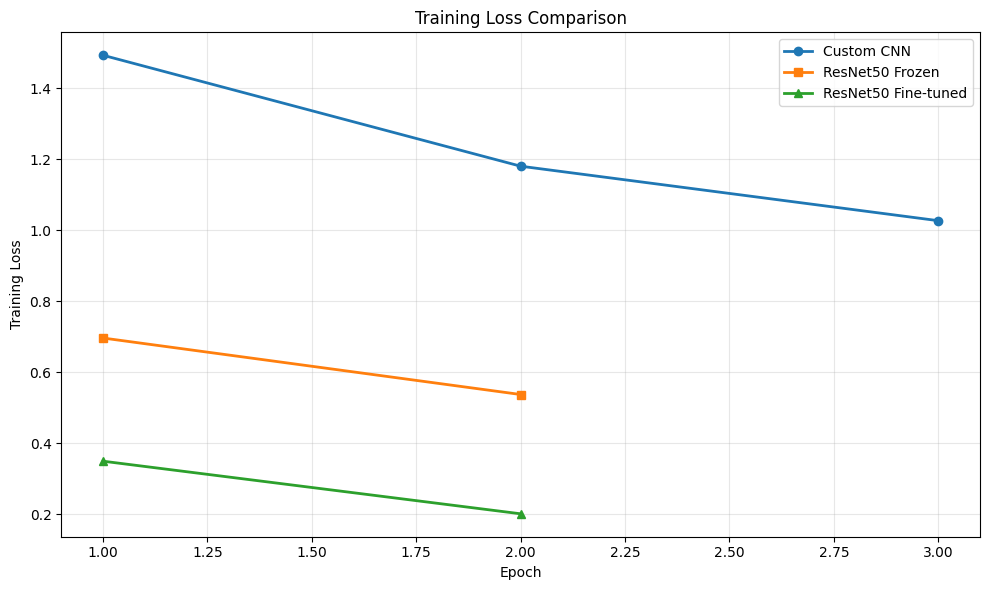

In [ ]:
# -----------------------------
# Visualization 3: Training Loss Comparison
# -----------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(baseline_history["train_loss"]) + 1),
    baseline_history["train_loss"],
    marker="o",
    linewidth=2,
    label="Custom CNN"
)

plt.plot(
    range(1, len(transfer_history["train_loss"]) + 1),
    transfer_history["train_loss"],
    marker="s",
    linewidth=2,
    label="ResNet50 Frozen"
)

plt.plot(
    range(1, len(finetune_history["train_loss"]) + 1),
    finetune_history["train_loss"],
    marker="^",
    linewidth=2,
    label="ResNet50 Fine-tuned"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "training_loss_comparison.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

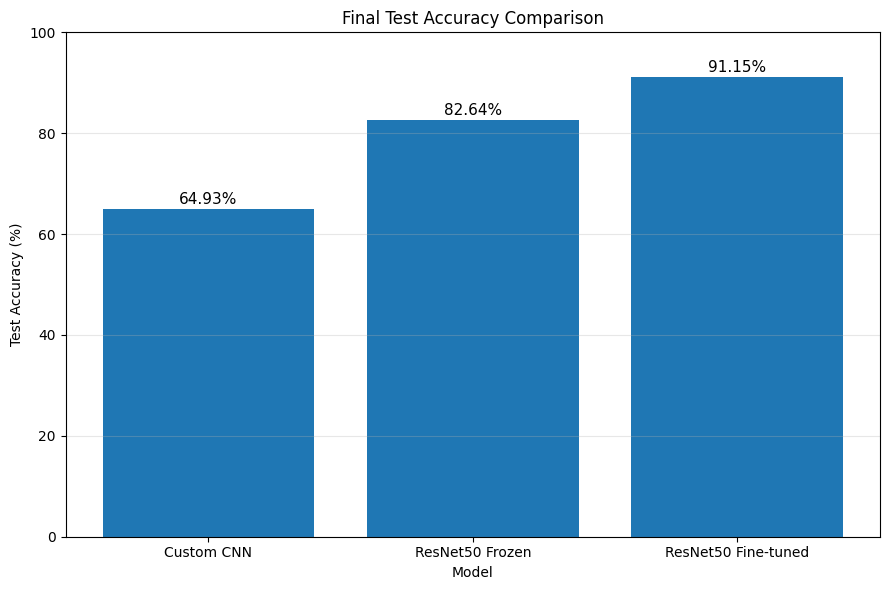

In [ ]:
# -----------------------------
# Visualization 4: Final Accuracy Bar Chart
# -----------------------------

model_names = [
    "Custom CNN",
    "ResNet50 Frozen",
    "ResNet50 Fine-tuned"
]

final_accuracies = [
    baseline_history["test_acc"][-1],
    transfer_history["test_acc"][-1],
    finetune_history["test_acc"][-1]
]

plt.figure(figsize=(9, 6))

bars = plt.bar(model_names, final_accuracies)

plt.ylabel("Test Accuracy (%)")
plt.xlabel("Model")
plt.title("Final Test Accuracy Comparison")
plt.ylim(0, 100)
plt.grid(axis="y", alpha=0.3)

for bar, value in zip(bars, final_accuracies):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.2f}%",
        ha="center",
        fontsize=11
    )

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "final_accuracy_comparison.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

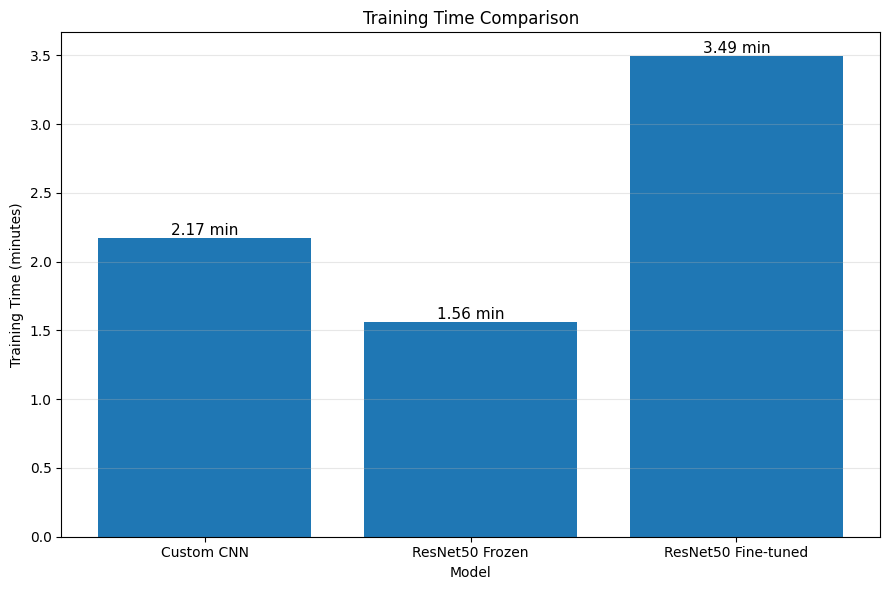

In [ ]:
# -----------------------------
# Visualization 5: Training Time Comparison
# -----------------------------

# Frozen ResNet training time + fine-tuning time
total_resnet_time = transfer_time + finetune_time

model_names = [
    "Custom CNN",
    "ResNet50 Frozen",
    "ResNet50 Fine-tuned"
]

training_times = [
    baseline_time / 60,
    transfer_time / 60,
    total_resnet_time / 60
]

plt.figure(figsize=(9, 6))

bars = plt.bar(model_names, training_times)

plt.ylabel("Training Time (minutes)")
plt.xlabel("Model")
plt.title("Training Time Comparison")
plt.grid(axis="y", alpha=0.3)

for bar, value in zip(bars, training_times):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.2f} min",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "training_time_comparison.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [ ]:
finetune_time

115.77286371899982

In [ ]:
[name for name in globals() if "model" in name.lower()]

['models', 'train_model', 'transfer_model', 'model_names']

In [ ]:
# -----------------------------
# 7. Fine-tuning: ResNet50 layer4 + classifier
# -----------------------------

import copy

# Start from the trained frozen ResNet50
finetune_model = copy.deepcopy(transfer_model)

# Freeze everything first
for param in finetune_model.parameters():
    param.requires_grad = False

# Unfreeze layer4
for param in finetune_model.layer4.parameters():
    param.requires_grad = True

# Keep the final classifier trainable
for param in finetune_model.fc.parameters():
    param.requires_grad = True

finetune_model = finetune_model.to(DEVICE)

print(
    "ResNet50 Fine-tuned total parameters:",
    count_parameters(finetune_model)
)

print(
    "ResNet50 Fine-tuned trainable parameters:",
    count_parameters(finetune_model, True)
)

# Train layer4 + classifier
finetune_history, finetune_time, finetune_best = train_model(
    finetune_model,
    train_loader,
    test_loader,
    FINETUNE_EPOCHS,
    LEARNING_RATE_FINETUNE,
    "ResNet50 Fine-tuned"
)

print(f"Fine-tuning time: {finetune_time / 60:.2f} minutes")
print(f"Best fine-tuned accuracy: {finetune_best:.2f}%")

ResNet50 Fine-tuned total parameters: 23528522
ResNet50 Fine-tuned trainable parameters: 14985226
ResNet50 Fine-tuned | Epoch 1/2 | Train Loss 0.1676 | Test Loss 0.2338 | Test Acc 91.91%
ResNet50 Fine-tuned | Epoch 2/2 | Train Loss 0.1110 | Test Loss 0.2173 | Test Acc 92.79%
Fine-tuning time: 1.90 minutes
Best fine-tuned accuracy: 92.79%


In [ ]:
print("Fine-tuned model exists:", "finetune_model" in globals())
print("Fine-tuning history exists:", "finetune_history" in globals())
print("Fine-tuning time exists:", "finetune_time" in globals())

Fine-tuned model exists: True
Fine-tuning history exists: True
Fine-tuning time exists: True


In [ ]:
total_parameters = [
    count_parameters(baseline),
    count_parameters(transfer_model),
    count_parameters(finetune_model)
]

trainable_parameters = [
    count_parameters(baseline, True),
    count_parameters(transfer_model, True),
    count_parameters(finetune_model, True)
]

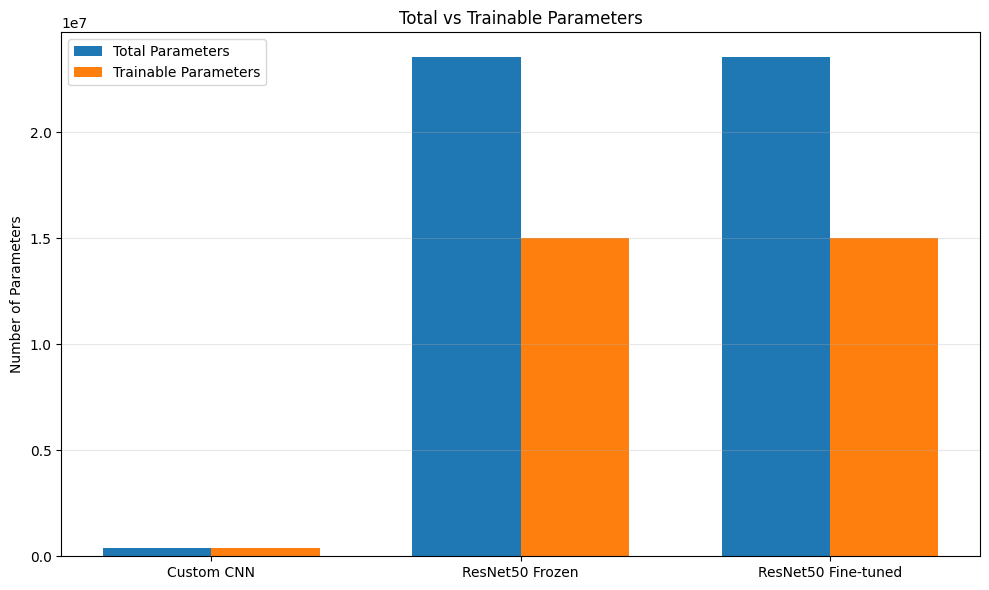

In [ ]:
# -----------------------------
# Visualization 6: Parameter Comparison
# -----------------------------

model_names = [
    "Custom CNN",
    "ResNet50 Frozen",
    "ResNet50 Fine-tuned"
]

total_parameters = [
    count_parameters(baseline),
    count_parameters(transfer_model),
    count_parameters(finetune_model)
]

trainable_parameters = [
    count_parameters(baseline, True),
    count_parameters(transfer_model, True),
    count_parameters(finetune_model, True)
]

x = np.arange(len(model_names))
width = 0.35

plt.figure(figsize=(10, 6))

bars1 = plt.bar(
    x - width / 2,
    total_parameters,
    width,
    label="Total Parameters"
)

bars2 = plt.bar(
    x + width / 2,
    trainable_parameters,
    width,
    label="Trainable Parameters"
)

plt.xticks(x, model_names)
plt.ylabel("Number of Parameters")
plt.title("Total vs Trainable Parameters")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "parameter_comparison.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

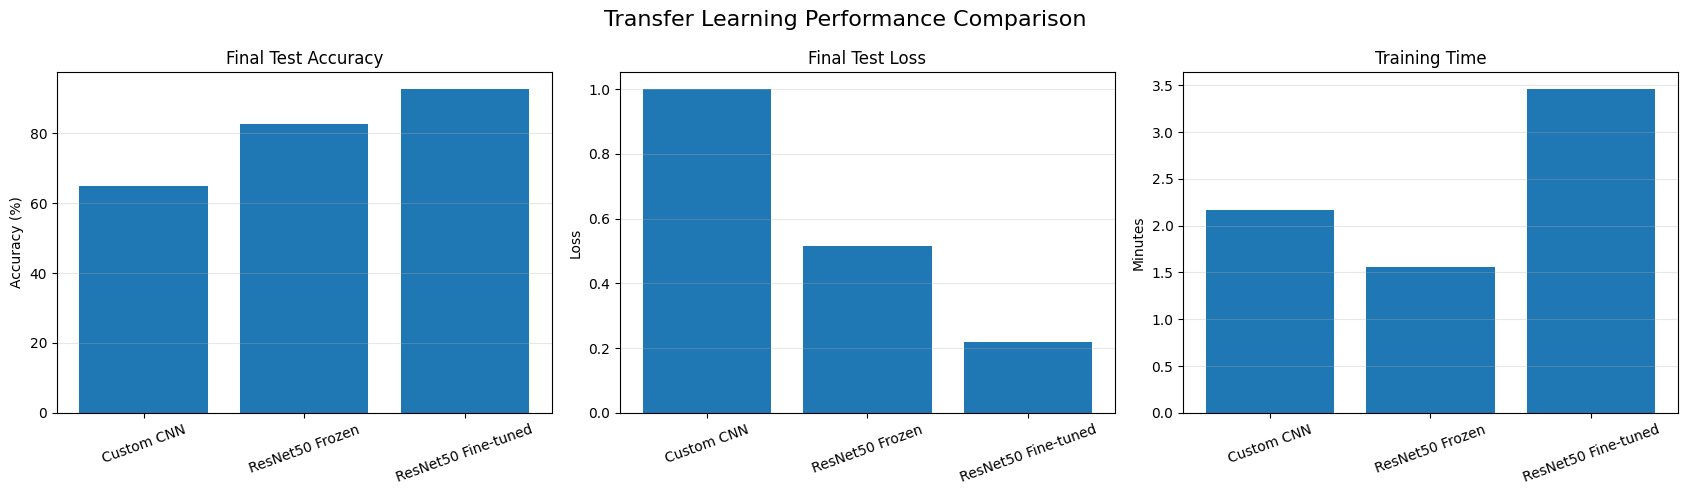

In [ ]:
# -----------------------------
# Visualization 7: Overall Performance Dashboard
# -----------------------------

models_list = [
    "Custom CNN",
    "ResNet50 Frozen",
    "ResNet50 Fine-tuned"
]

accuracy_values = [
    baseline_history["test_acc"][-1],
    transfer_history["test_acc"][-1],
    finetune_history["test_acc"][-1]
]

loss_values = [
    baseline_history["test_loss"][-1],
    transfer_history["test_loss"][-1],
    finetune_history["test_loss"][-1]
]

time_values = [
    baseline_time / 60,
    transfer_time / 60,
    (transfer_time + finetune_time) / 60
]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Accuracy
axes[0].bar(models_list, accuracy_values)
axes[0].set_title("Final Test Accuracy")
axes[0].set_ylabel("Accuracy (%)")
axes[0].tick_params(axis="x", rotation=20)
axes[0].grid(axis="y", alpha=0.3)

# Loss
axes[1].bar(models_list, loss_values)
axes[1].set_title("Final Test Loss")
axes[1].set_ylabel("Loss")
axes[1].tick_params(axis="x", rotation=20)
axes[1].grid(axis="y", alpha=0.3)

# Time
axes[2].bar(models_list, time_values)
axes[2].set_title("Training Time")
axes[2].set_ylabel("Minutes")
axes[2].tick_params(axis="x", rotation=20)
axes[2].grid(axis="y", alpha=0.3)

plt.suptitle(
    "Transfer Learning Performance Comparison",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "overall_performance_dashboard.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# -----------------------------
# Final Numerical Comparison
# -----------------------------

print("=" * 75)
print("FINAL MODEL COMPARISON")
print("=" * 75)

print(f"{'Model':<25} {'Accuracy':>12} {'Loss':>12} {'Time (min)':>15}")
print("-" * 75)

print(
    f"{'Custom CNN':<25} "
    f"{baseline_history['test_acc'][-1]:>11.2f}% "
    f"{baseline_history['test_loss'][-1]:>12.4f} "
    f"{baseline_time/60:>14.2f}"
)

print(
    f"{'ResNet50 Frozen':<25} "
    f"{transfer_history['test_acc'][-1]:>11.2f}% "
    f"{transfer_history['test_loss'][-1]:>12.4f} "
    f"{transfer_time/60:>14.2f}"
)

print(
    f"{'ResNet50 Fine-tuned':<25} "
    f"{finetune_history['test_acc'][-1]:>11.2f}% "
    f"{finetune_history['test_loss'][-1]:>12.4f} "
    f"{(transfer_time + finetune_time)/60:>14.2f}"
)

print("=" * 75)

accuracy_improvement = (
    finetune_history["test_acc"][-1]
    - baseline_history["test_acc"][-1]
)

print(
    f"\nFine-tuned ResNet50 vs Custom CNN: "
    f"{accuracy_improvement:+.2f} percentage points"
)

FINAL MODEL COMPARISON
Model                         Accuracy         Loss      Time (min)
---------------------------------------------------------------------------
Custom CNN                      64.93%       1.0019           2.17
ResNet50 Frozen                 82.64%       0.5150           1.56
ResNet50 Fine-tuned             92.79%       0.2173           3.47

Fine-tuned ResNet50 vs Custom CNN: +27.86 percentage points


# **Git Hub Link:-**